
## Notebook 1: Khám phá dữ liệu (EDA) & Tiền xử lý dữ liệu nâng cao (Preprocessing)

---
**Mô tả:**
Notebook này đại diện cho giai đoạn đầu tiên của quy trình xử lý dữ liệu khoa học (Data Science Pipeline). Chúng ta sẽ tiến hành khảo sát dữ liệu giao dịch thẻ tín dụng (Credit Card Fraud Detection), phân tích chuyên sâu sự mất cân bằng lớp nghiêm trọng, trực quan hóa mối tương quan giữa các đặc trưng, và xây dựng song song hai pipeline tiền xử lý (chuẩn hóa):
1. **Phương pháp chuẩn hóa cổ điển:** Sử dụng `StandardScaler` của thư viện Scikit-Learn.
2. **Phương pháp chuẩn hóa phân tán (Big Data Ready):** Khởi tạo và sử dụng Spark Engine thông qua `PySpark` để xử lý dữ liệu ở quy mô lớn.

---

In [1]:
# Cài đặt thư viện cần thiết
# Hỗ trợ tích hợp chạy PySpark trên môi trường cục bộ hoặc trên Kaggle Notebook
!pip install -q pyspark findspark

In [2]:
# Import các thư viện lõi phục vụ EDA và Tiền xử lý
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Cấu hình phong cách biểu đồ thống nhất cho toàn bộ dự án
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Cố định giá trị ngẫu nhiên
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("[LOG] Import thư viện hoàn tất. Sẵn sàng xử lý dữ liệu.")

[LOG] Import thư viện hoàn tất. Sẵn sàng xử lý dữ liệu.


In [3]:
# CELL 3: Đọc dataset với cơ chế leo cây thư mục tìm kiếm tự động
import os
import glob

# Tự động phát hiện thư mục gốc và file raw/creditcard.csv độc lập môi trường làm việc Cwd
def find_raw_csv():
    curr = os.path.abspath(os.getcwd())
    # Tìm kiếm đệ quy đi lên 5 cấp thư mục để phát hiện data/raw/creditcard.csv
    for _ in range(5):
        candidate = os.path.join(curr, "data", "raw", "creditcard.csv")
        if os.path.exists(candidate):
            return candidate
        curr = os.path.dirname(curr)
    
    # Dự phòng tìm kiếm đệ quy đi xuống nếu đang ở thư mục cha
    matches = glob.glob("**/creditcard.csv", recursive=True)
    if matches:
        return matches[0]
    return "data/raw/creditcard.csv"

csv_path = find_raw_csv()

if not os.path.exists(csv_path):
    raise FileNotFoundError(
        f"[ERROR] Không tìm thấy file creditcard.csv tại '{csv_path}'. "
        "Vui lòng đặt dataset vào thư mục 'data/raw/' của project."
    )

print(f"[LOG] Đang đọc dữ liệu từ đường dẫn: {csv_path}")
df = pd.read_csv(csv_path)
print(f"[LOG] Đọc dữ liệu thành công! Kích thước dữ liệu: {df.shape[0]:,} dòng, {df.shape[1]} cột.")


[LOG] Đang đọc dữ liệu từ đường dẫn: sample_data/creditcard.csv
[LOG] Đọc dữ liệu thành công! Kích thước dữ liệu: 284,807 dòng, 31 cột.


In [4]:
# CELL 4: Khảo sát sơ bộ cấu trúc dữ liệu
print("=== 5 dòng đầu tiên của tập dữ liệu ===")
display(df.head())

print("\n=== Kích thước tập dữ liệu ===")
print(f"Hàng: {df.shape[0]:,}\nCột: {df.shape[1]}")

print("\n=== Thông tin chi tiết các trường dữ liệu (Schema & Dtypes) ===")
df.info()

print("\n=== Thống kê mô tả (Descriptive Statistics) ===")
display(df.describe())

=== 5 dòng đầu tiên của tập dữ liệu ===


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



=== Kích thước tập dữ liệu ===
Hàng: 284,807
Cột: 31

=== Thông tin chi tiết các trường dữ liệu (Schema & Dtypes) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18  

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
# CELL 5: Kiểm tra các giá trị khuyết thiếu (Missing values)
print("[LOG] Bắt đầu quét dữ liệu khuyết thiếu...")
missing_count = df.isnull().sum()
total_missing = missing_count.sum()

print(f"[LOG] Tổng số ô bị khuyết thiếu (Null/NaN) trên toàn bộ bảng: {total_missing}")
if total_missing > 0:
    print("\n[WARNING] Chi tiết số lượng khuyết thiếu tại từng cột:")
    display(missing_count[missing_count > 0])
else:
    print("[LOG] Dữ liệu hoàn hảo! Không phát hiện bất kỳ trường khuyết thiếu nào.")

[LOG] Bắt đầu quét dữ liệu khuyết thiếu...
[LOG] Tổng số ô bị khuyết thiếu (Null/NaN) trên toàn bộ bảng: 0
[LOG] Dữ liệu hoàn hảo! Không phát hiện bất kỳ trường khuyết thiếu nào.


=== Bảng Tần Suất Lớp (Class Frequency Table) ===
 Lớp 0 [Bình thường (Normal)]:   284,315 giao dịch | Tỷ lệ: 99.8273%
 Lớp 1 [Gian lận (Fraud)    ]:       492 giao dịch | Tỷ lệ: 0.1727%


/tmp/ipykernel_1268/3664533115.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Class', data=df, palette=palette_colors)


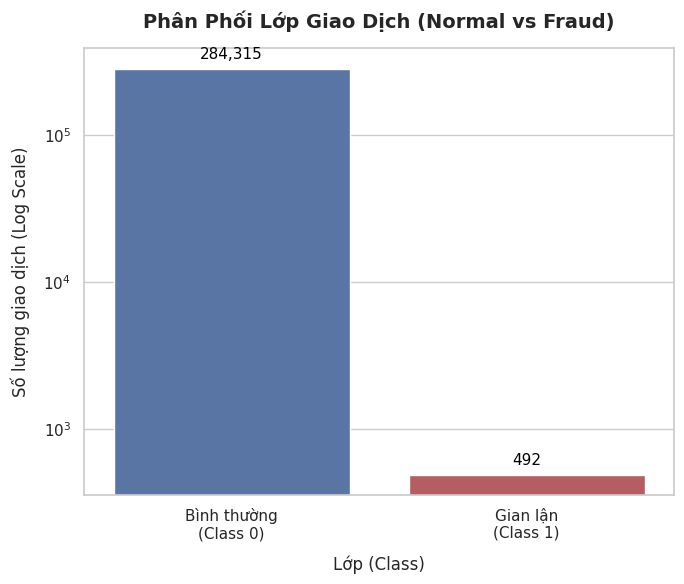

In [6]:
# CELL 6: Phân tích mất cân bằng lớp (Imbalance Analysis)
class_counts = df['Class'].value_counts()
class_percentages = df['Class'].value_counts(normalize=True) * 100

print("=== Bảng Tần Suất Lớp (Class Frequency Table) ===")
for idx, count in class_counts.items():
    label = "Bình thường (Normal)" if idx == 0 else "Gian lận (Fraud)"
    print(f" Lớp {idx} [{label:20}]: {count:9,} giao dịch | Tỷ lệ: {class_percentages[idx]:.4f}%")

# Trực quan hóa mất cân bằng bằng Seaborn
plt.figure(figsize=(7, 6))
palette_colors = ["#4C72B0", "#C44E52"] # Xanh dương nhã nhặn cho Normal, Đỏ gạch cho Fraud
ax = sns.countplot(x='Class', data=df, palette=palette_colors)

plt.title("Phân Phối Lớp Giao Dịch (Normal vs Fraud)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Lớp (Class)", fontsize=12, labelpad=10)
plt.ylabel("Số lượng giao dịch (Log Scale)", fontsize=12, labelpad=10)
plt.xticks(ticks=[0, 1], labels=["Bình thường\n(Class 0)", "Gian lận\n(Class 1)"], fontsize=11)
plt.yscale('log') # Áp dụng Log Scale vì sự chênh lệch quá lớn giữa 2 lớp

# Thêm giá trị cụ thể lên đỉnh cột
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=11, color='black',
                xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

[LOG] Đang tính toán ma trận tương quan giữa các đặc trưng...


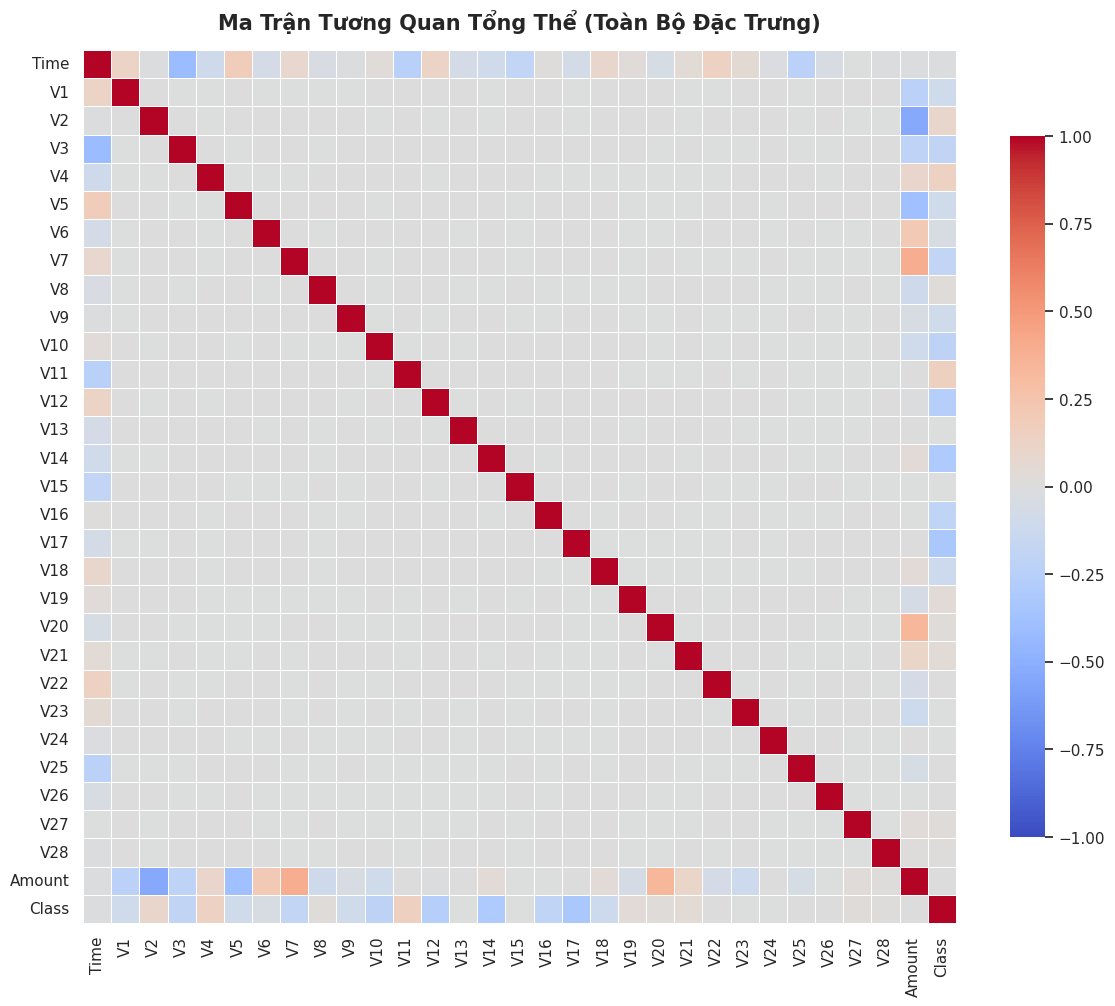


=== Mức độ tương quan âm mạnh nhất với nhãn Class (Top 5) ===
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64

=== Mức độ tương quan dương mạnh nhất với nhãn Class (Top 5) ===
V11    0.154876
V4     0.133447
V2     0.091289
V21    0.040413
V19    0.034783
Name: Class, dtype: float64


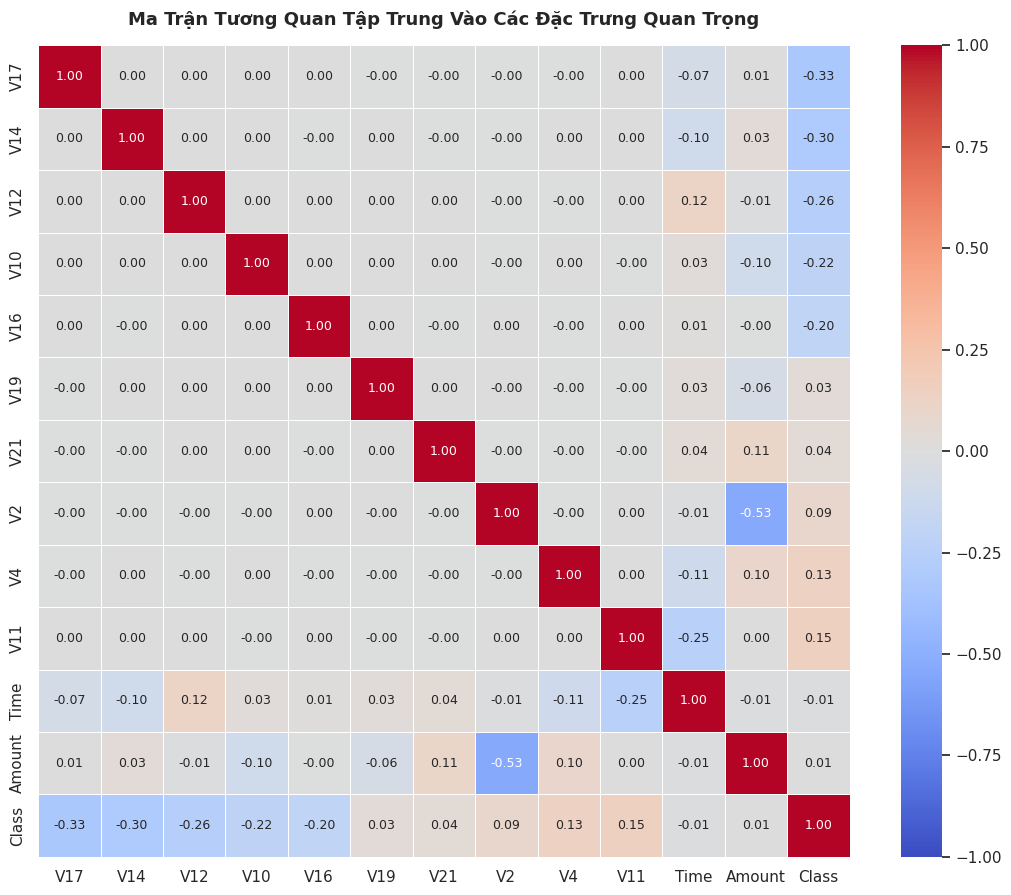

In [7]:
# CELL 7: Phân tích tương quan đặc trưng (Correlation Analysis)
print("[LOG] Đang tính toán ma trận tương quan giữa các đặc trưng...")
corr_full = df.corr()

# Vẽ ma trận tương quan tổng thể
plt.figure(figsize=(12, 10))
sns.heatmap(corr_full, cmap='coolwarm', vmin=-1, vmax=1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Ma Trận Tương Quan Tổng Thể (Toàn Bộ Đặc Trưng)", fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Trực quan hóa ma trận tương quan tập trung vào Time, Amount và các biến V1-V28 ảnh hưởng mạnh nhất tới Class
class_corr = corr_full['Class'].sort_values()
print("\n=== Mức độ tương quan âm mạnh nhất với nhãn Class (Top 5) ===")
print(class_corr.head(5))
print("\n=== Mức độ tương quan dương mạnh nhất với nhãn Class (Top 5) ===")
print(class_corr.tail(6).drop('Class')[::-1])

# Lấy top 5 tương quan âm, top 5 tương quan dương kết hợp với Time và Amount
selected_features = list(class_corr.head(5).index) + list(class_corr.tail(6).drop('Class').index) + ['Time', 'Amount', 'Class']
selected_features = list(dict.fromkeys(selected_features)) # Loại bỏ trùng lặp nếu có

plt.figure(figsize=(11, 9))
sns.heatmap(df[selected_features].corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0,
            square=True, linewidths=.5, annot_kws={"size": 9})
plt.title("Ma Trận Tương Quan Tập Trung Vào Các Đặc Trưng Quan Trọng", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

###  Giải thích ý nghĩa của Sự Mất Cân Bằng Lớp và Hệ Số Tương Quan

#### 1. Mất Cân Bằng Lớp (Imbalanced Data)
* **Bản chất hiện tượng:** Dữ liệu có sự chênh lệch khủng khiếp giữa lớp chiếm đa số (Normal - $99.827\%$) và lớp thiểu số (Fraud - chỉ vỏn vẹn $0.173\%$). Cứ khoảng $578$ giao dịch bình thường mới xuất hiện $1$ giao dịch gian lận.
* **Hệ quả đối với Machine Learning:**
  * Nếu chúng ta huấn luyện trực tiếp một mô hình phân loại trên dữ liệu thô này mà không có sự điều chỉnh, mô hình sẽ có xu hướng "lười biếng" (Naive Classifier) - luôn dự đoán mọi giao dịch là *Bình thường (Class 0)*.
  * Khi đó, độ chính xác tổng thể (Accuracy) vẫn đạt mức **$99.827\%$**, nhưng mô hình hoàn toàn vô dụng vì bỏ lọt toàn bộ $100\%$ các giao dịch gian lận. Do đó, Accuracy là một metric tồi tệ đối với dữ liệu mất cân bằng. Chúng ta bắt buộc phải sử dụng các metric thay thế như **Precision, Recall, F1-Score** và **ROC-AUC**.

#### 2. Phân Tích Hệ Số Tương Quan (Correlation Analysis)
* **Nhận xét từ Heatmap:**
  * Các biến từ $V_1$ đến $V_{28}$ là kết quả của phép biến đổi PCA (Principal Component Analysis). Về mặt lý thuyết toán học, các thành phần chính này độc lập tuyến tính với nhau, do đó hệ số tương quan giữa chúng xấp xỉ bằng $0$ (thể hiện rõ qua vùng màu xanh nhạt trung tính trên heatmap tổng thể).
  * Tuy nhiên, khi đối chiếu tương quan với biến mục tiêu `Class`, ta phát hiện một số đặc trưng có mối quan hệ rõ rệt:
    * **Tương quan âm mạnh:** $V_{17}$ ($-0.327$), $V_{14}$ ($-0.303$), $V_{12}$ ($-0.260$), $V_{10}$ ($-0.217$). Khi giá trị các biến này giảm xuống, xác suất xảy ra giao dịch gian lận tăng lên mạnh mẽ.
    * **Tương quan dương mạnh:** $V_{11}$ ($0.155$), $V_4$ ($0.133$), $V_2$ ($0.091$). Khi giá trị các đặc trưng này tăng lên, nguy cơ xảy ra giao dịch gian lận cũng tăng theo.
    * **Time và Amount:** Có tương quan tuyến tính rất yếu với `Class`. Điều này phản ánh rằng hành vi gian lận không phụ thuộc đơn giản theo hàm tuyến tính vào thời gian hay số tiền giao dịch, đòi hỏi mô hình phi tuyến tính phức tạp hơn.

In [9]:
# Phân tách Đặc Trưng (Features) và Nhãn Mục Tiêu (Label)
X = df.drop(columns=['Class'])
y = df['Class']

print("[LOG] Phân tách thành công:")
print(f" - Khung chứa các đặc trưng (X): {X.shape[0]:,} mẫu, {X.shape[1]} đặc trưng.")
print(f" - Vector chứa nhãn mục tiêu (y): {y.shape[0]:,} phần tử.")

[LOG] Phân tách thành công:
 - Khung chứa các đặc trưng (X): 284,807 mẫu, 30 đặc trưng.
 - Vector chứa nhãn mục tiêu (y): 284,807 phần tử.


In [10]:
# Chia tập dữ liệu thành Train và Test (Train/Test Split)
# Tỷ lệ chia: 80% Train, 20% Test
# Sử dụng stratify=y để giữ nguyên tỷ lệ nhãn cực kỳ mất cân bằng ở cả hai tập, tránh lệch phân phối
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("[LOG] Phân chia Train/Test thành công!")
print(f" - Số mẫu tập huấn luyện (Train): {X_train.shape[0]:,} ({X_train.shape[0]/df.shape[0]*100:.1f}%)")
print(f" - Số mẫu tập kiểm thử (Test): {X_test.shape[0]:,} ({X_test.shape[0]/df.shape[0]*100:.1f}%)")
print(f" - Số lượng Fraud trên tập Train: {y_train.sum()} ({y_train.mean()*100:.4f}%)")
print(f" - Số lượng Fraud trên tập Test: {y_test.sum()} ({y_test.mean()*100:.4f}%)")

[LOG] Phân chia Train/Test thành công!
 - Số mẫu tập huấn luyện (Train): 227,845 (80.0%)
 - Số mẫu tập kiểm thử (Test): 56,962 (20.0%)
 - Số lượng Fraud trên tập Train: 394 (0.1729%)
 - Số lượng Fraud trên tập Test: 98 (0.1720%)


In [11]:
# CELL 11: [Cách cũ - Scikit-Learn] Chuẩn hóa các đặc trưng Time và Amount
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

cols_to_scale = ['Time', 'Amount']
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
print("[LOG] Chuẩn hóa Time và Amount bằng StandardScaler (Scikit-Learn) thành công.")

# Tự động phát hiện/tạo thư mục data/processed và models
def find_export_paths():
    curr = os.path.abspath(os.getcwd())
    for _ in range(5):
        if os.path.exists(os.path.join(curr, "data")) or os.path.exists(os.path.join(curr, "README.md")):
            processed_path = os.path.join(curr, "data", "processed")
            models_path = os.path.join(curr, "models")
            os.makedirs(processed_path, exist_ok=True)
            os.makedirs(models_path, exist_ok=True)
            return processed_path, models_path
        curr = os.path.dirname(curr)
    return "../data/processed", "../models"

PROCESSED_DIR, MODELS_DIR = find_export_paths()

# Lưu scaler.pkl đồng bộ sang cả hai thư mục phục vụ cho cả Pipeline và model production
import pickle
with open(os.path.join(PROCESSED_DIR, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)
with open(os.path.join(MODELS_DIR, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)
    
print(f"[LOG] Đã đồng bộ và lưu bộ chuẩn hóa Scaler thành công vào:")
print(f" - '{os.path.join(PROCESSED_DIR, 'scaler.pkl')}'")
print(f" - '{os.path.join(MODELS_DIR, 'scaler.pkl')}'")

print("\n=== Thống kê mô tả sau khi chuẩn hóa (Time & Amount) ===")
display(X_train_scaled[cols_to_scale].describe())


[LOG] Chuẩn hóa Time và Amount bằng StandardScaler (Scikit-Learn) thành công.
[LOG] Đã lưu bộ chuẩn hóa Scaler thành công vào 'processed_data/scaler.pkl'.

=== Thống kê mô tả sau khi chuẩn hóa (Time & Amount) ===


,Time,Amount
count,2.278450e+05,2.278450e+05
mean,-1.407707e-16,-2.020811e-17
std,1.000002e+00,1.000002e+00
min,-1.998073e+00,-3.516894e-01
25%,-8.561495e-01,-3.291944e-01
50%,-2.122647e-01,-2.639429e-01
75%,9.366285e-01,-4.262209e-02
max,1.640549e+00,1.021170e+02


In [12]:
# [Cách mới nâng cao] Khởi tạo SparkSession bằng PySpark
print("[LOG] Bắt đầu tích hợp Spark Engine cục bộ...")
import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler as SparkStandardScaler
from pyspark.sql.functions import col

try:
    spark = SparkSession.builder \
        .appName("CreditCardFraudPreprocessing") \
        .master("local[*]") \
        .config("spark.driver.memory", "4g") \
        .config("spark.executor.memory", "4g") \
        .getOrCreate()

    print(f"[SUCCESS] Khởi tạo thành công SparkSession. Spark Version: {spark.version}")
    spark_enabled = True
except Exception as e:
    print(f"[WARNING] Không thể khởi động Spark: {e}")
    print("[WARNING] Hệ thống sẽ bỏ qua việc thực thi PySpark và sử dụng Scikit-Learn đã hoàn tất làm mặc định.")
    spark_enabled = False

[LOG] Bắt đầu tích hợp Spark Engine cục bộ...
[SUCCESS] Khởi tạo thành công SparkSession. Spark Version: 4.0.2


In [13]:
# CELL 13: Đọc CSV bằng Spark DataFrame
if spark_enabled:
    print(f"[LOG] Spark đang tiến hành nạp dữ liệu từ: {csv_path}")
    spark_df = spark.read.csv(csv_path, header=True, inferSchema=True)

    print(f"[LOG] Spark DataFrame nạp thành công!")
    print(f"Số dòng: {spark_df.count():,}, Số cột: {len(spark_df.columns)}")
    spark_df.printSchema()
else:
    print("[INFO] Spark không khả dụng. Bỏ qua bước này.")

[LOG] Spark đang tiến hành nạp dữ liệu từ: sample_data/creditcard.csv
[LOG] Spark DataFrame nạp thành công!
Số dòng: 284,807, Số cột: 31
root
 |-- Time: double (nullable = true)
 |-- V1: double (nullable = true)
 |-- V2: double (nullable = true)
 |-- V3: double (nullable = true)
 |-- V4: double (nullable = true)
 |-- V5: double (nullable = true)
 |-- V6: double (nullable = true)
 |-- V7: double (nullable = true)
 |-- V8: double (nullable = true)
 |-- V9: double (nullable = true)
 |-- V10: double (nullable = true)
 |-- V11: double (nullable = true)
 |-- V12: double (nullable = true)
 |-- V13: double (nullable = true)
 |-- V14: double (nullable = true)
 |-- V15: double (nullable = true)
 |-- V16: double (nullable = true)
 |-- V17: double (nullable = true)
 |-- V18: double (nullable = true)
 |-- V19: double (nullable = true)
 |-- V20: double (nullable = true)
 |-- V21: double (nullable = true)
 |-- V22: double (nullable = true)
 |-- V23: double (nullable = true)
 |-- V24: double (nullable

In [14]:
# CELL 14: gom các đặc trưng thành Vector duy nhất bằng VectorAssembler
if spark_enabled:
    # Lấy danh sách các cột đặc trưng loại trừ cột nhãn 'Class'
    feature_cols = [c for c in spark_df.columns if c != 'Class']

    # Gom nhóm
    assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_vector")
    spark_vector_df = assembler.transform(spark_df)

    print("[LOG] Tạo Vector đặc trưng bằng VectorAssembler thành công.")
    spark_vector_df.select("features_vector", "Class").show(3, truncate=True)
else:
    print("[INFO] Spark không khả dụng. Bỏ qua bước này.")

[LOG] Tạo Vector đặc trưng bằng VectorAssembler thành công.
+--------------------+-----+
|     features_vector|Class|
+--------------------+-----+
|[0.0,-1.359807133...|    0|
|[0.0,1.1918571113...|    0|
|[1.0,-1.358354061...|    0|
+--------------------+-----+
only showing top 3 rows


In [15]:
# CELL 15: Sử dụng StandardScaler của PySpark chuẩn hóa dữ liệu lớn
if spark_enabled:
    # Khởi tạo Spark StandardScaler để chuẩn hóa vector đặc trưng
    # withStd=True: Chia cho độ lệch chuẩn
    # withMean=True: Trừ đi giá trị trung bình để đưa kỳ vọng về 0
    spark_scaler = SparkStandardScaler(inputCol="features_vector", outputCol="scaled_features",
                                        withStd=True, withMean=True)

    # Huấn luyện bộ chuẩn hóa
    spark_scaler_model = spark_scaler.fit(spark_vector_df)

    # Thực hiện chuẩn hóa trên toàn bộ tập dữ liệu
    spark_scaled_df = spark_scaler_model.transform(spark_vector_df)

    print("[LOG] Chuẩn hóa toàn diện bằng PySpark StandardScaler thành công.")
    spark_scaled_df.select("scaled_features", "Class").show(3, truncate=True)
else:
    print("[INFO] Spark không khả dụng. Bỏ qua bước này.")

[LOG] Chuẩn hóa toàn diện bằng PySpark StandardScaler thành công.
+--------------------+-----+
|     scaled_features|Class|
+--------------------+-----+
|[-1.9965795183032...|    0|
|[-1.9965795183032...|    0|
|[-1.9965584604164...|    0|
+--------------------+-----+
only showing top 3 rows


### Giải Thích Tầm Quan Trọng và Kiến Trúc PySpark Trong Tiền Xử Lý Dữ Liệu Lớn

#### 1. Catalyst Optimizer là gì?
* **Khái niệm:** Đây là trái tim tối ưu hóa của Spark SQL và DataFrame API. Catalyst Optimizer tận dụng các tính năng lập trình hàm trong ngôn ngữ Scala để xây dựng một cây thực thi tối ưu qua 4 giai đoạn chính:
  1. **Analysis:** Phân tích cú pháp DataFrame để đối chiếu với catalog của Spark nhằm kiểm tra tính hợp lệ của các cột và kiểu dữ liệu.
  2. **Logical Optimization:** Áp dụng các quy tắc tối ưu hóa logic như *Constant Folding* (tính toán hằng số trước), *Predicate Pushdown* (đẩy bộ lọc dữ liệu xuống gần nguồn đọc nhất), và *Projection Pruning* (chỉ giữ lại các cột cần thiết).
  3. **Physical Planning:** Sinh ra nhiều kế hoạch vật lý khả thi và chạy mô hình chi phí (Cost-based Model) để chọn ra kế hoạch tiêu tốn ít RAM/CPU nhất.
  4. **Code Generation:** Sử dụng tính năng Quasar CodeGen để biên dịch kế hoạch vật lý tối ưu trực tiếp thành mã bytecode Java cực nhanh khi thực thi thực tế.

#### 2. Khả năng Scale dữ liệu lớn và kiến trúc phân tán
* Khác với Pandas vốn chạy đơn luồng (Single-thread) và bị giới hạn bởi dung lượng RAM vật lý của một máy tính (gây ra lỗi kinh điển `OutOfMemory`), PySpark hoạt động dựa trên mô hình **Master-Worker** phân tán:
  * Dữ liệu được chia thành các phân vùng (Partitions) nhỏ nằm rải rác trên nhiều máy tính khác nhau (HDFS hoặc Cloud Storage).
  * Spark thực hiện cơ chế **Lazy Evaluation** (đánh giá lười biếng): Các lệnh biến đổi dữ liệu (Transformations) như `VectorAssembler` hay `StandardScaler` sẽ không được chạy ngay lập tức, mà chỉ được ghi nhận vào đồ thị **DAG** (Directed Acyclic Graph). Dữ liệu chỉ thực sự được xử lý khi xuất hiện lệnh kích hoạt (Actions) như `show()`, `count()`, hay `write()`.
  * Nhờ đó, chúng ta có thể mở rộng (scale-out) hệ thống một cách tuyến tính bằng cách bổ sung thêm node phần cứng để xử lý dữ liệu lên tới hàng Terabytes hay Petabytes mà không cần sửa đổi bất kỳ dòng code tiền xử lý nào.

In [16]:
# CELL 16: Xuất dữ liệu đã chuẩn hóa ra các tệp trung gian phục vụ huấn luyện mô hình
print("[LOG] Bắt đầu ghi dữ liệu ra đĩa...")

# Tự động phát hiện/tạo thư mục data/processed
def find_processed_dir():
    curr = os.path.abspath(os.getcwd())
    for _ in range(5):
        if os.path.exists(os.path.join(curr, "data")) or os.path.exists(os.path.join(curr, "README.md")):
            processed_path = os.path.join(curr, "data", "processed")
            os.makedirs(processed_path, exist_ok=True)
            return processed_path
        curr = os.path.dirname(curr)
    return "../data/processed"

OUTPUT_DIR = find_processed_dir()

# Xuất các file dữ liệu dạng CSV để Notebook 2 nạp vào dễ dàng
X_train_scaled.to_csv(os.path.join(OUTPUT_DIR, "X_train_scaled.csv"), index=False)
X_test_scaled.to_csv(os.path.join(OUTPUT_DIR, "X_test_scaled.csv"), index=False)
y_train.to_csv(os.path.join(OUTPUT_DIR, "y_train.csv"), index=False)
y_test.to_csv(os.path.join(OUTPUT_DIR, "y_test.csv"), index=False)

print("[LOG] Dữ liệu tiền xử lý đã được lưu trữ thành công tại:")
print(f" - {os.path.join(OUTPUT_DIR, 'X_train_scaled.csv')} ({os.path.getsize(os.path.join(OUTPUT_DIR, 'X_train_scaled.csv'))/1024/1024:.2f} MB)")
print(f" - {os.path.join(OUTPUT_DIR, 'X_test_scaled.csv')} ({os.path.getsize(os.path.join(OUTPUT_DIR, 'X_test_scaled.csv'))/1024/1024:.2f} MB)")
print(f" - {os.path.join(OUTPUT_DIR, 'y_train.csv')} ({os.path.getsize(os.path.join(OUTPUT_DIR, 'y_train.csv'))/1024/1024:.2f} MB)")
print(f" - {os.path.join(OUTPUT_DIR, 'y_test.csv')} ({os.path.getsize(os.path.join(OUTPUT_DIR, 'y_test.csv'))/1024/1024:.2f} MB)")

if spark_enabled:
    # Giải phóng tài nguyên Spark Session sau khi hoàn tất
    spark.stop()
    print("[LOG] Đã đóng Spark Session thành công. Tài nguyên đã được giải phóng hoàn toàn.")


[LOG] Bắt đầu ghi dữ liệu ra đĩa...
[LOG] Dữ liệu tiền xử lý đã được lưu trữ thành công tại:
 - processed_data/X_train_scaled.csv (120.24 MB)
 - processed_data/X_test_scaled.csv (30.06 MB)
 - processed_data/y_train.csv (0.43 MB)
 - processed_data/y_test.csv (0.11 MB)
[LOG] Đã đóng Spark Session thành công. Tài nguyên đã được giải phóng hoàn toàn.
